# Football Match Outcome Prediction

Run this notebook from the project folder (the one that contains `main.py`).
Run the cells from top to bottom: **Kernel -> Restart & Run All**.

What it does: loads Premier League results and Bet365 odds, builds leak-free features, trains models (logistic regression, gradient boosting, a Poisson goals model, a Dixon-Coles model) and compares them with the bookmaker probabilities using walk-forward evaluation. The cells below show the result tables and plots (log loss, RPS, bootstrap intervals, Diebold-Mariano tests, blend with the bookmaker, margin removal, Dixon-Coles, and whether form and Elo add information beyond the odds). See the README for the explanations.

## 1. Install the libraries (needed only once)

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Settings

In [2]:
import pandas as pd
from IPython.display import Image, display
import main

# league codes: E0 Premier League, D1 Bundesliga, SP1 La Liga, I1 Serie A, F1 Ligue 1
LEAGUES = ["E0"]          # for example ["E0", "D1", "SP1", "I1", "F1"]
USE_CLUBELO = False       # experimental: needs the ClubElo web service (not reachable when tested)

## 3. Run the whole pipeline

The first run downloads the data (about a minute). Later runs use the cached files in `data/`.

In [3]:
main.run(LEAGUES, USE_CLUBELO)

Leagues: E0
Matches loaded: 5700
Test seasons: 1920, 2021, 2122, 2223, 2324, 2425



Season 1920: tuned Elo K=30, home advantage=100 (validation log loss 0.9159)


  train matches: 3345  test matches: 377


  blend weights chosen on validation season 1819 (share of model): Logistic regression 0.1, Gradient boosting 0.0, Poisson goals model 0.2
  over 2.5 goals log loss - Poisson model: 0.6779, base rate: 0.6922
  always predicting a home win: accuracy 0.454


  Dixon-Coles: xi=0.002 chosen on validation season 1819 (validation log loss per xi: 0.000: 0.9206, 0.001: 0.9000, 0.002: 0.8952, 0.003: 0.8965, 0.005: 0.9015), blend weight 0.4
  Dixon-Coles: 32 refits, 0 not converged, 0 matches with an unseen team, rho clipped 0 times, 9 seconds
  odds model A vs A + features B: likelihood-ratio test on the training seasons chi2=14.41 (df=14), p=0.4199; converged: True



...


Test season 2425 in detail:
           approach  log_loss  accuracy  bets  profit_units  roi_percent
  Class frequencies    1.0816     0.408   450        -50.66        -11.3
 Bookmaker (Bet365)    0.9738     0.538     0          0.00          0.0
Logistic regression    0.9954     0.507   242        -34.53        -14.3
  Gradient boosting    1.0173     0.515   351        -74.91        -21.3
Poisson goals model    0.9915     0.507   244        -35.93        -14.7



Log loss minus bookmaker log loss, 95% bootstrap CI (1000 resamples).
Negative = better than the bookmaker; the CI must stay below 0 to support that.
season                   approach  loss_difference  ci_low  ci_high
  1920          Class frequencies           0.0916  0.0434   0.1369
  1920        Logistic regression           0.0041 -0.0183   0.0260
  1920          Gradient boosting           0.0207 -0.0083   0.0468
  1920        Poisson goals model          -0.0033 -0.0250   0.0157
  1920 Blend: Logistic regression          -0.0016 -0.0039   0.0005
  1920   Blend: Gradient boosting           0.0000  0.0000   0.0000
  1920 Blend: Poisson goals model          -0.0040 -0.0086  -0.0001
  2021          Class frequencies           0.0828  0.0346   0.1258
  2021        Logistic regression           0.0427  0.0190   0.0668
  2021          Gradient boosting           0.0397  0.0124   0.0684
  2021        Poisson goals model           0.0346  0.0138   0.0569
  2021 Blend: Logistic regression


Bookmaker probabilities with three margin removal methods (same test matches):
      method season  log_loss    rps
proportional   1920    0.9725 0.1987
proportional   2021    1.0101 0.2143
proportional   2122    0.9341 0.1887
proportional   2223    0.9649 0.1988
proportional   2324    0.9132 0.1848
proportional   2425    0.9738 0.1983
proportional   mean    0.9614 0.1973
       power   1920    0.9746 0.1991
       power   2021    1.0136 0.2151
       power   2122    0.9325 0.1884
       power   2223    0.9651 0.1988
       power   2324    0.9103 0.1841
       power   2425    0.9743 0.1985
       power   mean    0.9617 0.1973
        shin   1920    0.9742 0.1990
        shin   2021    1.0126 0.2148
        shin   2122    0.9329 0.1885
        shin   2223    0.9648 0.1987
        shin   2324    0.9111 0.1843
        shin   2425    0.9739 0.1984
        shin   mean    0.9616 0.1973

Favourite-longshot check, all 5700 matches (actual - predicted < 0 for longshots would mean the bias exis


Dixon-Coles versus the other approaches (same test matches):
           approach season  log_loss    rps
  Class frequencies   1920    1.0640 0.2300
  Class frequencies   2021    1.0929 0.2466
  Class frequencies   2122    1.0698 0.2359
  Class frequencies   2223    1.0498 0.2284
  Class frequencies   2324    1.0559 0.2337
  Class frequencies   2425    1.0816 0.2358
  Class frequencies   mean    1.0690 0.2351
 Bookmaker (Bet365)   1920    0.9725 0.1987
 Bookmaker (Bet365)   2021    1.0101 0.2143
 Bookmaker (Bet365)   2122    0.9341 0.1887
 Bookmaker (Bet365)   2223    0.9649 0.1988
 Bookmaker (Bet365)   2324    0.9132 0.1848
 Bookmaker (Bet365)   2425    0.9738 0.1983
 Bookmaker (Bet365)   mean    0.9614 0.1973
Poisson goals model   1920    0.9692 0.1982
Poisson goals model   2021    1.0448 0.2248
Poisson goals model   2122    0.9554 0.1963
Poisson goals model   2223    0.9951 0.2088
Poisson goals model   2324    0.9332 0.1914
Poisson goals model   2425    0.9915 0.2046
Poisson goals 


Saved results/metrics.csv, results/walk_forward.csv, results/bootstrap.csv,
results/blend.csv, results/rps.csv, results/dm.csv, results/margin_methods.csv,
results/bookmaker_calibration.csv, results/favourite_longshot.csv,
results/bookmaker_calibration.png, results/dixon_coles.csv,
results/dixon_coles_tests.csv, results/dixon_coles_draw_share.csv,
results/dixon_coles_parameters.csv, results/features_vs_odds.csv,
results/features_vs_odds_coefficients.csv and results/calibration.png


## 4. Walk-forward log loss (lower is better)

In [4]:
pd.read_csv("results/walk_forward.csv")

,approach,1920,2021,2122,2223,2324,2425,mean
0,Class frequencies,1.0640,1.0929,1.0698,1.0498,1.0559,1.0816,1.0690
1,Bookmaker (Bet365),0.9725,1.0101,0.9341,0.9649,0.9132,0.9738,0.9614
2,Logistic regression,0.9765,1.0528,0.9573,0.9955,0.9346,0.9954,0.9854
3,Gradient boosting,0.9932,1.0498,0.9624,1.0165,0.9495,1.0173,0.9981
4,Poisson goals model,0.9692,1.0448,0.9554,0.9951,0.9332,0.9915,0.9815


## 5. Latest test season in detail

In [5]:
pd.read_csv("results/metrics.csv")

,approach,log_loss,accuracy,bets,profit_units,roi_percent
0,Class frequencies,1.0816,0.408,450,-50.66,-11.3
1,Bookmaker (Bet365),0.9738,0.538,0,0.00,0.0
2,Logistic regression,0.9954,0.507,242,-34.53,-14.3
3,Gradient boosting,1.0173,0.515,351,-74.91,-21.3
4,Poisson goals model,0.9915,0.507,244,-35.93,-14.7


## 6. Calibration of the home-win probabilities

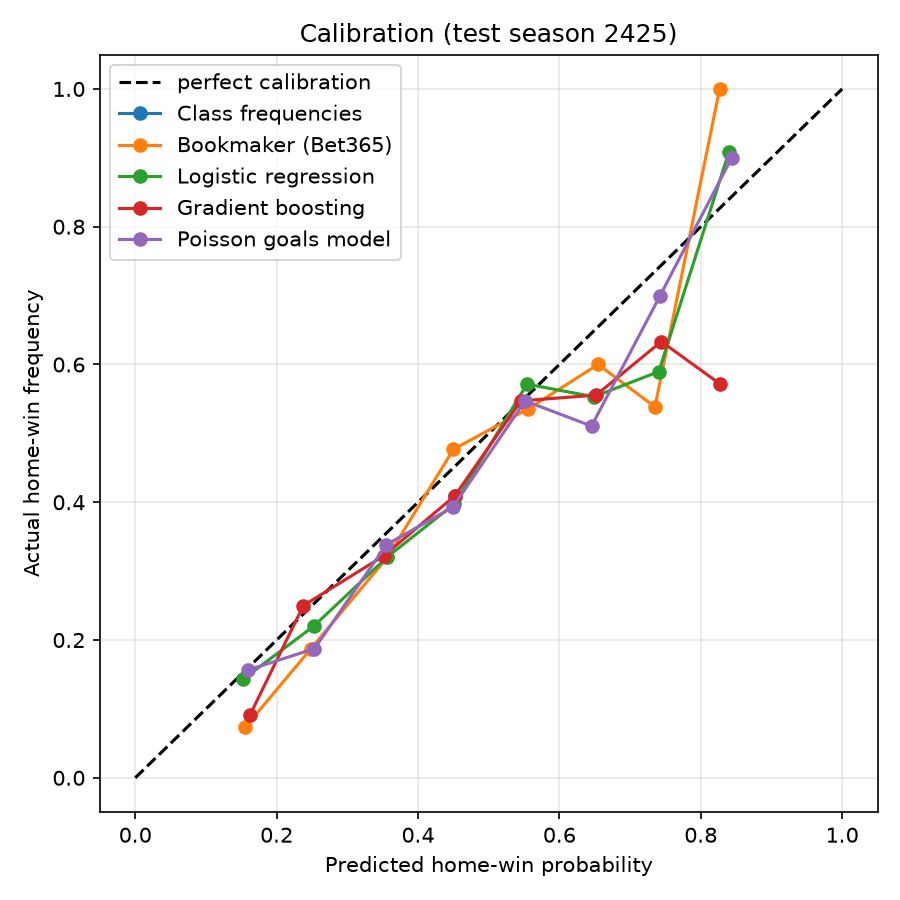

In [6]:
display(Image("results/calibration.png"))

## 7. Bootstrap: log loss minus bookmaker log loss (95% CI)

Negative = better than the bookmaker. The whole interval must be below 0 to support that claim.

In [7]:
pd.read_csv("results/bootstrap.csv")

,season,approach,loss_difference,ci_low,ci_high
0,1920,Class frequencies,0.0916,0.0434,0.1369
1,1920,Logistic regression,0.0041,-0.0183,0.0260
2,1920,Gradient boosting,0.0207,-0.0083,0.0468
3,1920,Poisson goals model,-0.0033,-0.0250,0.0157
4,1920,Blend: Logistic regression,-0.0016,-0.0039,0.0005
5,1920,Blend: Gradient boosting,0.0000,0.0000,0.0000
6,1920,Blend: Poisson goals model,-0.0040,-0.0086,-0.0001
7,2021,Class frequencies,0.0828,0.0346,0.1258
8,2021,Logistic regression,0.0427,0.0190,0.0668
9,2021,Gradient boosting,0.0397,0.0124,0.0684


## 8. Blend of model and bookmaker

`model_weight` was chosen on the validation season, never on the test season.

In [8]:
pd.read_csv("results/blend.csv")

,season,model,model_weight,model_log_loss,bookmaker_log_loss,blend_log_loss
0,1920,Logistic regression,0.1,0.9765,0.9725,0.9708
1,1920,Gradient boosting,0.0,0.9932,0.9725,0.9725
2,1920,Poisson goals model,0.2,0.9692,0.9725,0.9684
3,2021,Logistic regression,0.4,1.0528,1.0101,1.0206
4,2021,Gradient boosting,0.2,1.0498,1.0101,1.0115
5,2021,Poisson goals model,0.6,1.0448,1.0101,1.0254
6,2122,Logistic regression,0.0,0.9573,0.9341,0.9341
7,2122,Gradient boosting,0.0,0.9624,0.9341,0.9341
8,2122,Poisson goals model,0.0,0.9554,0.9341,0.9341
9,2223,Logistic regression,0.0,0.9955,0.9649,0.9649


## 9. Ranked Probability Score (lower is better)

RPS uses the order home win < draw < away win.

In [9]:
pd.read_csv("results/rps.csv")

,approach,1920,2021,2122,2223,2324,2425,mean
0,Class frequencies,0.2300,0.2466,0.2359,0.2284,0.2337,0.2358,0.2351
1,Logistic regression,0.1994,0.2255,0.1962,0.2094,0.1914,0.2058,0.2046
2,Gradient boosting,0.2027,0.2250,0.1962,0.2148,0.1946,0.2093,0.2071
3,Poisson goals model,0.1982,0.2248,0.1963,0.2088,0.1914,0.2046,0.2040
4,Blend: Logistic regression,0.1981,0.2169,0.1887,0.1988,0.1857,0.1983,0.1978
5,Blend: Gradient boosting,0.1987,0.2148,0.1887,0.1997,0.1848,0.1983,0.1975
6,Blend: Poisson goals model,0.1976,0.2189,0.1887,0.1988,0.1850,0.1983,0.1979
7,Bookmaker (Bet365),0.1987,0.2143,0.1887,0.1988,0.1848,0.1983,0.1973


## 10. Diebold-Mariano test against the bookmaker

Difference = approach - bookmaker (positive = worse). `mean` is a plain average of the per-season numbers, `pooled` is one test on all test matches. p-values are not corrected for the many tests.

In [10]:
pd.read_csv("results/dm.csv")

,season,approach,log_loss_diff,dm_stat_log_loss,dm_p_log_loss,rps_diff,dm_stat_rps,dm_p_rps
0,1920,Class frequencies,0.091600,3.752000,0.000176,0.031240,3.941000,0.000081
1,1920,Logistic regression,0.004100,0.366000,0.714427,0.000720,0.216000,0.828612
2,1920,Gradient boosting,0.020700,1.499000,0.133960,0.003950,1.030000,0.303227
3,1920,Poisson goals model,-0.003300,-0.312000,0.754955,-0.000480,-0.152000,0.878890
4,1920,Blend: Logistic regression,-0.001600,-1.490000,0.136232,-0.000570,-1.757000,0.078876
5,1920,Blend: Gradient boosting,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
6,1920,Blend: Poisson goals model,-0.004000,-1.823000,0.068359,-0.001120,-1.780000,0.075140
7,2021,Class frequencies,0.082800,3.542000,0.000397,0.032220,4.207000,0.000026
8,2021,Logistic regression,0.042700,3.528000,0.000419,0.011110,3.028000,0.002464
9,2021,Gradient boosting,0.039700,2.644000,0.008204,0.010630,2.540000,0.011079


## 11. Bookmaker margin: proportional, power and Shin

Log loss and RPS of the bookmaker probabilities on the test matches (`mean` = average over the test seasons).

In [11]:
pd.read_csv("results/margin_methods.csv")

,method,season,log_loss,rps
0,proportional,1920,0.9725,0.1987
1,proportional,2021,1.0101,0.2143
2,proportional,2122,0.9341,0.1887
3,proportional,2223,0.9649,0.1988
4,proportional,2324,0.9132,0.1848
5,proportional,2425,0.9738,0.1983
6,proportional,mean,0.9614,0.1973
7,power,1920,0.9746,0.1991
8,power,2021,1.0136,0.2151
9,power,2122,0.9325,0.1884


## 12. Favourite-longshot bias of the bookmaker probabilities

`actual_minus_predicted` below 0 for longshots and above 0 for favourites would show the bias.

In [12]:
pd.read_csv("results/favourite_longshot.csv")

,method,group,observations,mean_predicted,actual_frequency,actual_minus_predicted,std_error
0,proportional,longshots (probability below 0.20),3535,0.1375,0.1383,0.0008,0.0058
1,proportional,middle (0.20 to 0.50),10529,0.3098,0.3053,-0.0045,0.0045
2,proportional,favourites (0.50 or more),3036,0.6430,0.6574,0.0145,0.0086
3,power,longshots (probability below 0.20),3683,0.1313,0.1393,0.0080,0.0057
4,power,middle (0.20 to 0.50),10210,0.3069,0.3040,-0.0029,0.0046
5,power,favourites (0.50 or more),3207,0.6495,0.6495,0.0000,0.0084
6,shin,longshots (probability below 0.20),3619,0.1328,0.1395,0.0068,0.0058
7,shin,middle (0.20 to 0.50),10285,0.3069,0.3032,-0.0038,0.0045
8,shin,favourites (0.50 or more),3196,0.6454,0.6499,0.0045,0.0084


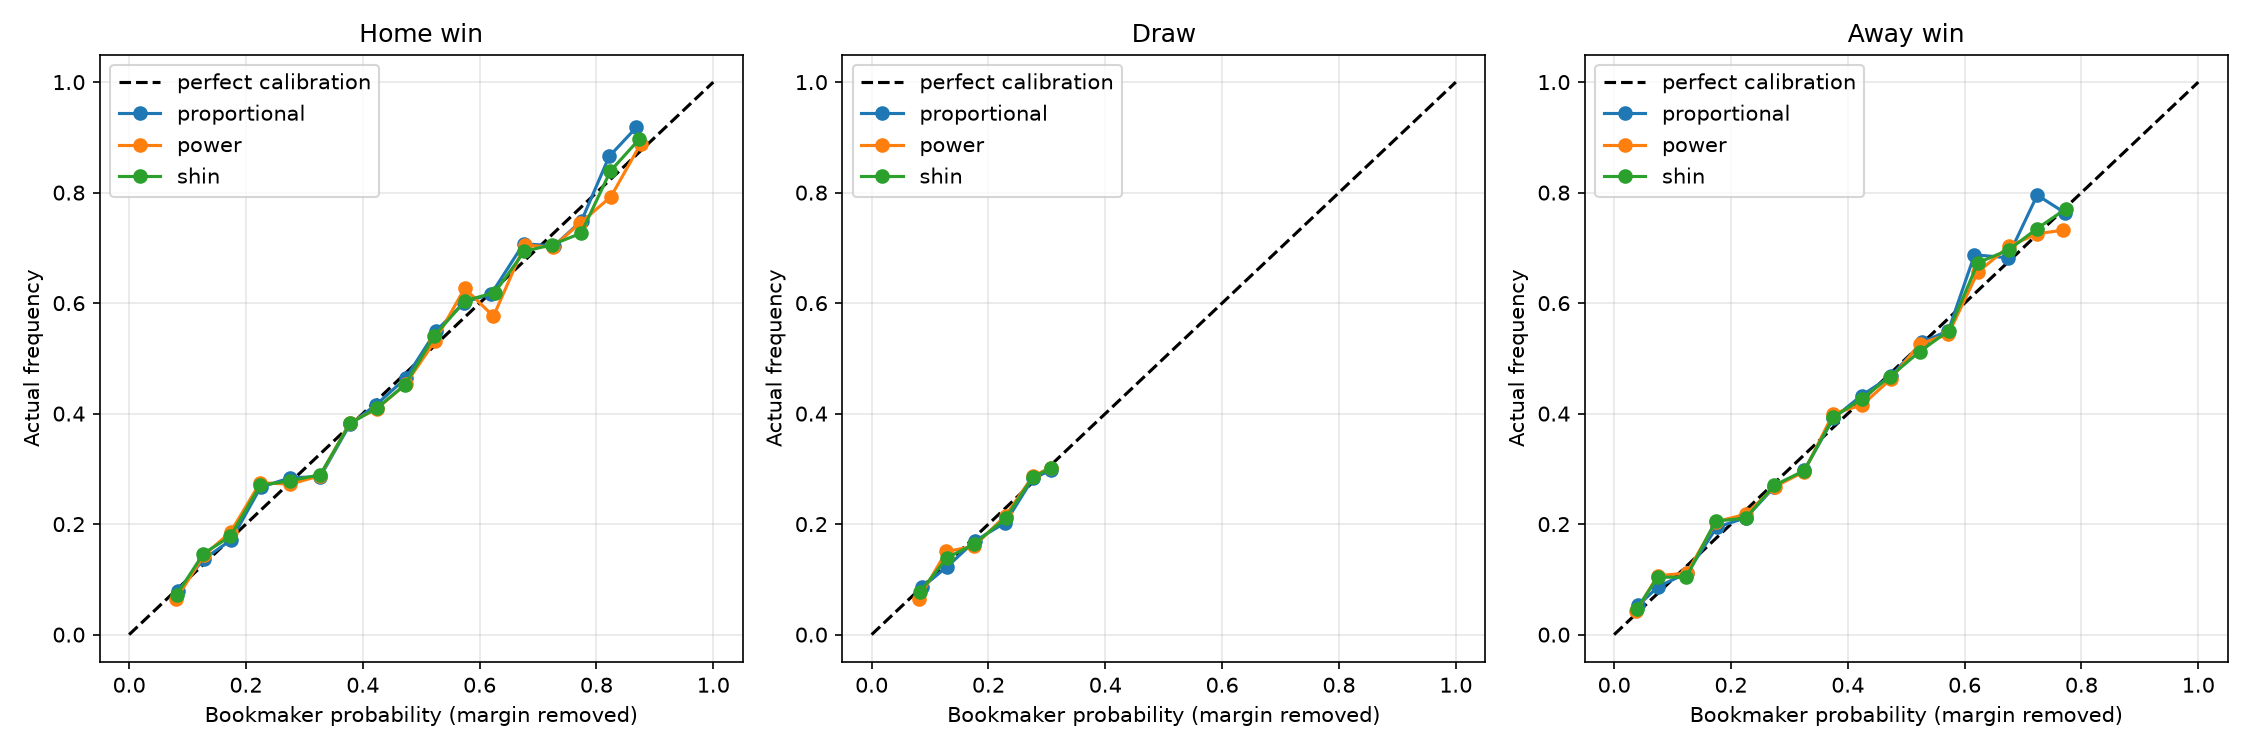

In [13]:
display(Image("results/bookmaker_calibration.png"))

## 13. Dixon-Coles goals model

Attack and defence per team, home advantage, a correction `rho` for the low scores 0-0, 1-0, 0-1, 1-1 and a time decay `xi` (chosen on the validation season). Log loss and RPS on the same test matches as all other approaches.

In [14]:
pd.read_csv("results/dixon_coles.csv")

,approach,season,log_loss,rps
0,Class frequencies,1920,1.0640,0.2300
1,Class frequencies,2021,1.0929,0.2466
2,Class frequencies,2122,1.0698,0.2359
3,Class frequencies,2223,1.0498,0.2284
4,Class frequencies,2324,1.0559,0.2337
5,Class frequencies,2425,1.0816,0.2358
6,Class frequencies,mean,1.0690,0.2351
7,Bookmaker (Bet365),1920,0.9725,0.1987
8,Bookmaker (Bet365),2021,1.0101,0.2143
9,Bookmaker (Bet365),2122,0.9341,0.1887


## 14. Dixon-Coles against the bookmaker and against the Poisson model

Difference = first minus second (positive = Dixon-Coles is worse). `ci_low` / `ci_high` is the 95% bootstrap interval of the log loss difference, `dm_p_*` the Diebold-Mariano p-values (not corrected for many tests).

In [15]:
pd.read_csv("results/dixon_coles_tests.csv")

,season,comparison,log_loss_diff,dm_stat_log_loss,dm_p_log_loss,rps_diff,dm_stat_rps,dm_p_rps,ci_low,ci_high
0,1920,Dixon-Coles vs Bookmaker,-0.003700,-0.408000,0.683084,-0.000380,-0.136000,0.891672,-0.022300,0.014600
1,1920,Dixon-Coles vs Poisson goals model,-0.000400,-0.055000,0.956381,0.000100,0.047000,0.962134,-0.015500,0.015600
2,1920,Blend: Dixon-Coles vs Bookmaker,-0.005200,-1.384000,0.166460,-0.001300,-1.164000,0.244555,-0.013100,0.002300
3,2021,Dixon-Coles vs Bookmaker,0.010200,1.187000,0.235162,0.002780,1.000000,0.317109,-0.006900,0.027200
4,2021,Dixon-Coles vs Poisson goals model,-0.024500,-2.929000,0.003404,-0.007720,-3.082000,0.002055,-0.039500,-0.009700
5,2021,Blend: Dixon-Coles vs Bookmaker,0.002800,0.540000,0.588914,0.000650,0.390000,0.696628,-0.007700,0.013200
6,2122,Dixon-Coles vs Bookmaker,0.015500,1.676000,0.093703,0.005470,1.903000,0.057007,-0.002100,0.034700
7,2122,Dixon-Coles vs Poisson goals model,-0.005900,-0.727000,0.467219,-0.002080,-0.826000,0.408933,-0.021200,0.011000
8,2122,Blend: Dixon-Coles vs Bookmaker,0.000100,0.123000,0.902201,0.000110,0.386000,0.699809,-0.001700,0.002000
9,2223,Dixon-Coles vs Bookmaker,0.040400,4.027000,0.000056,0.013460,4.079000,0.000045,0.020300,0.058900


## 15. Share of draws, 0-0 and 1-1: predicted versus real

In [16]:
pd.read_csv("results/dixon_coles_draw_share.csv")

,season,model,predicted_draw,actual_draw,predicted_0_0,actual_0_0,predicted_1_1,actual_1_1
0,1920,Dixon-Coles,0.2453,0.2414,0.0752,0.0557,0.1143,0.1273
1,1920,Poisson goals model,0.2223,0.2414,0.0620,0.0557,0.1056,0.1273
2,1920,Bookmaker (Bet365),0.2378,0.2414,NaN,NaN,NaN,NaN
3,2021,Dixon-Coles,0.2454,0.2202,0.0758,0.0796,0.1135,0.1061
4,2021,Poisson goals model,0.2314,0.2202,0.0647,0.0796,0.1099,0.1061
5,2021,Bookmaker (Bet365),0.2433,0.2202,NaN,NaN,NaN,NaN
6,2122,Dixon-Coles,0.2362,0.2281,0.0710,0.0557,0.1094,0.1088
7,2122,Poisson goals model,0.2287,0.2281,0.0637,0.0557,0.1086,0.1088
8,2122,Bookmaker (Bet365),0.2397,0.2281,NaN,NaN,NaN,NaN
9,2223,Dixon-Coles,0.2366,0.2281,0.0667,0.0610,0.1107,0.0981


## 16. Dixon-Coles settings and fit diagnostics

`xi` and the blend weight were chosen on the validation season; `valid_log_loss_xi_*` shows the validation log loss for every `xi`.

In [17]:
pd.read_csv("results/dixon_coles_parameters.csv")

,season,xi,mean_rho,mean_home_advantage,blend_weight,refits,not_converged,matches_with_unseen_team,rho_clipped,valid_log_loss_xi_0.0,valid_log_loss_xi_0.001,valid_log_loss_xi_0.002,valid_log_loss_xi_0.003,valid_log_loss_xi_0.005
0,1920,0.002,-0.0617,0.2378,0.4,32,0,0,0,0.9206,0.9000,0.8952,0.8965,0.9015
1,2021,0.002,-0.0426,0.1723,0.6,33,0,0,0,0.9871,0.9694,0.9687,0.9716,0.9772
2,2122,0.002,-0.0245,0.1391,0.1,35,0,0,0,1.0330,1.0236,1.0203,1.0207,1.0258
3,2223,0.001,-0.0275,0.1943,0.1,33,0,0,0,0.9619,0.9474,0.9496,0.9532,0.9599
4,2324,0.005,0.0279,0.2149,0.0,35,0,0,0,1.0160,1.0052,0.9968,0.9916,0.9867
5,2425,0.001,-0.0152,0.1783,0.0,34,0,0,0,0.9485,0.9304,0.9305,0.9345,0.9422


## 17. Do form and Elo add information beyond the bookmaker odds?

Model A: multinomial logistic regression on the bookmaker log-odds ratios only. Model B: A plus the 7 form and Elo features. `lr_*` is the likelihood-ratio test of B against A on the training seasons (14 extra coefficients); the log losses are out-of-sample on the test season. `b_minus_a` below 0 would mean that the features help.

In [18]:
pd.read_csv("results/features_vs_odds.csv")

,season,train_matches,test_matches,lr_statistic,lr_df,lr_p_value,log_loss_bookmaker,log_loss_a,log_loss_b,b_minus_a,ci_low,ci_high,dm_p_b_vs_a,a_minus_bookmaker
0,1920,3345.0,377.0,14.4060,14.0,0.4199,0.9725,0.9699,0.9740,0.0041,-0.0023,0.0104,0.2403,-0.0026
1,2021,3722.0,377.0,13.1010,14.0,0.5186,1.0101,1.0187,1.0232,0.0045,-0.0030,0.0132,0.2508,0.0086
2,2122,4099.0,377.0,11.4990,14.0,0.6465,0.9341,0.9351,0.9372,0.0021,-0.0038,0.0078,0.4648,0.0010
3,2223,4476.0,377.0,13.0210,14.0,0.5249,0.9649,0.9646,0.9658,0.0012,-0.0054,0.0075,0.7267,-0.0002
4,2324,4853.0,377.0,13.8510,14.0,0.4609,0.9132,0.9124,0.9140,0.0016,-0.0040,0.0074,0.5731,-0.0008
5,2425,5230.0,377.0,13.1510,14.0,0.5147,0.9738,0.9764,0.9778,0.0014,-0.0034,0.0058,0.6041,0.0026
6,mean,NaN,NaN,13.1715,NaN,0.5142,0.9614,0.9628,0.9653,0.0025,-0.0037,0.0087,0.4766,0.0014
7,pooled,NaN,2262.0,NaN,NaN,NaN,0.9614,0.9629,0.9653,0.0025,-0.0001,0.0051,0.0593,0.0014


Coefficients of model B in every test season (fitted on the training seasons):

In [19]:
pd.read_csv("results/features_vs_odds_coefficients.csv")

,season,model,equation,term,coefficient,std_error,p_value
0,1920,B,draw vs home win,constant,0.1257,0.1414,0.3740
1,1920,B,draw vs home win,ln(pDraw/pHome),1.9341,0.5339,0.0003
2,1920,B,draw vs home win,ln(pAway/pHome),-0.6029,0.2992,0.0439
3,1920,B,draw vs home win,home_pts,0.1985,0.1034,0.0548
4,1920,B,draw vs home win,home_gf,-0.1421,0.0813,0.0803
...,...,...,...,...,...,...,...
115,2425,B,away win vs home win,home_ga,0.0471,0.0561,0.4020
116,2425,B,away win vs home win,away_pts,-0.1439,0.0798,0.0712
117,2425,B,away win vs home win,away_gf,0.0263,0.0629,0.6757
118,2425,B,away win vs home win,away_ga,-0.0588,0.0565,0.2983


## Notes

- The bookmaker already knows things the model does not (injuries, line-ups), so beating it in log loss is not expected. The goal is a correct, leakage-free pipeline and honest evaluation.
- The backtest covers a few hundred matches per season, so profit and ROI are noisy and are not evidence of a working betting strategy.